### BSM CS 3A - Computer Saiyans
ORLANDA, GABRIELLE SEBASTIAN P. 

MANALO, AIZLE 

HERNANDEZ, MARY MAPLE T.

ROSAL, JAM RUSSEL M.

TOMAS, MARK RENIEL R.

TORIBIO, JOHN ARVIN R.

# Graph Initialization

The following shows the Graph Converted from the Barangay Virgen Delas Flores, recording its Vertices (Intersections), Edges (Roads Connecting Intersections), and Weights (Distance between two nodes).

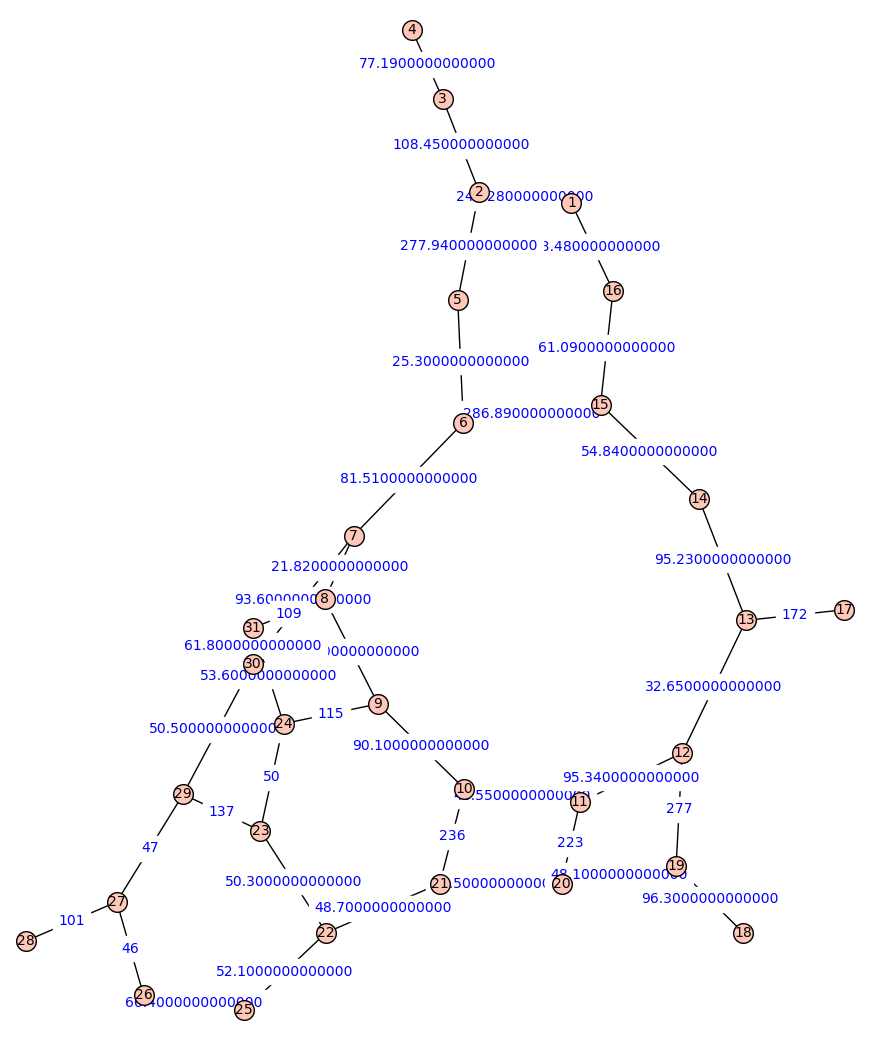

In [2]:
G = Graph([(1,2,249.28),(2,3,108.45),(3,4,77.19),(2,5,277.94),(1,16,473.48),(5,6,25.3),(6,15,286.89),
           (15,16,61.09),(6,7,81.51),(7,8,21.82),(7,30,93.6),(30,29,50.5),(29,27,47),(28,27,101),
           (27,26,46),(26,25,66.4),(25,22,52.1),(29,23,137),(30,31,61.8),(31,24,53.6),(8,9,50.75),
           (31,8,109),(24,9,115),(9,10,90.1),(22,21,48.7),(21,10,236),(21,20,51.5),(10,11,48.55),
           (20,11,223),(20,19,48.1),(11,12,95.34),(12,13,32.65),(19,12,277),(18,19,96.3),(17,13,172),
           (13,14,95.23),(14,15,54.84),(22,23,50.3),(24,23,50)])

G.show(edge_labels=True, figsize=14)

In [3]:
G.shortest_path(2,4,check_weight=True)
cost = G.shortest_path_length(2, 4, by_weight=True)
cost

185.64

### Initial Eulerian Check

The following code snippet checks if the following Graph stated in Graph G is Eulerian

In [4]:
# Check if the Graph is Eulerian for the Chinese Postman Problem
G.is_eulerian()

False

### Checking for Odd-Degree Vertices

The following code snippet focuses on how the program determines the odd-degree vertices of Graph G by first converting the graph into an Adjacency Matrix then running a simple for loop to determine which vertices along the graph is of odd-degree

In [5]:
# Lists the Adjacency Matrix of G
Adj = G.adjacency_matrix()
Adj.str()

'[0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]\n[1 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]\n[0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]\n[0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]\n[0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]\n[0 0 0 0 1 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]\n[0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0]\n[0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1]\n[0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0]\n[0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0]\n[0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0]\n[0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0]\n[0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0]\n[0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]\n[0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]\n[1 0 0 0 0 0 0 0 0 0 0 0

In [6]:
import numpy as np
Adj = np.array(Adj)
degrees = Adj.sum(axis=1)
vertex = 0
odd_vertices = []
for i in degrees:
    vertex += 1
    if i % 2 == 1:
        odd_vertices.append(vertex) # Adds that Vertex to the array if it is odd

odd_vertices = np.array(odd_vertices)
print("Odd Degree Vertices: ", len(odd_vertices))

Odd Degree Vertices:  24


## Odd-Vertices Check

The following are the Odd-Degree Vertices to be used for the Ant Colony Optimization Model

In [7]:
odd_vertices

array([ 2,  4,  6,  7,  8,  9, 10, 11, 12, 13, 15, 17, 18, 19, 20, 21, 22,
       23, 24, 27, 28, 29, 30, 31])

# Ant Colony Optimization


The following sections shows the detailed code of the Ant Colony Optimization, its functions, and how they are used.

## Global Variables Initialization

The following are the initialization of global values to be used throughout the computation of the Ant Colony Optimization Model. 

In [24]:
# Gloaval Variables
alpha = 1
beta = 3
rho = 0.1
Q = 1
Tao = {}

# Initializing Tao Matrix (2D Array)
for u in odd_vertices:
    for v in odd_vertices:
        if u != v:
            Tao[(u,v)] = 1

Best_Distance = 0
Best_Pairs = []
remaining_odds = odd_vertices

### Normalize Function 

The normalize function calculates the Probability that the vertex pairings will be chosen

In [23]:
def normalize():
    p = []
    i = remaining_odds[0]
    
    denom = 0
    for j in remaining_odds:
        if j == i:
            continue
        d = G.shortest_path_length(i, j, by_weight=True)
        denom += (Tao[(i,j)]**alpha) * (1/d)**beta

    for j in remaining_odds:
        if j == i:
            p.append(0)
            continue
        
        d = G.shortest_path_length(i, j, by_weight=True)
        num = (Tao[(i,j)]**alpha) * (1/d)**beta
        p.append(num / denom)
    
    return p

### Random Function

The following code shows a simple random function with a random import to randomize which vertex pairings will be chosen by using the probabilistic values from normalize()

In [12]:
import random

def choose():
    probabilities = normalize()
    i = remaining_odds[0]
    
    r = random.random()
    cumulative = 0
    
    for j, p in enumerate(probabilities):
        cumulative += p
        if r <= cumulative:
            return i, remaining_odds[j]

### Pairing Function

This function determines the pairs to be appended to the near-optimal solution by calling the choose() randomizing function.

In [14]:
def pairing():
    global remaining_odds
    pairs = []
    
    while len(remaining_odds) > 1:
        x, y = choose()
        pairs.append((x,y))
        remaining_odds = [v for v in remaining_odds if v != x and v != y]
    
    return pairs

### Pheromone Function

After a vertex pairing has been chosen, the Pheromone values Tao must be updated based on the chosen vertex pairings. This uses the equation Delta Tau = Q / (shortest path from the chosen vertices earlier) 

In [15]:
def update_pheromones(pairs):
    global Tao
    
    # Evaporation
    for edge in Tao:
        Tao[edge] *= (1 - rho)
    
    # Reinforcement
    for (u, v) in pairs:
        dist = G.shortest_path_length(u, v, by_weight=True)
        Tao[(u,v)] += Q / dist
        Tao[(v,u)] += Q / dist

### Main Function

This runs the entire Ant Colony Optimization Model by running the entire algorithm vertex pairings ten times (ten generations)

In [ ]:
def aco_run():
    for generation in range(10):
        remaining_odds = list(odd_vertices)
        
        pairs = pairing()
    
        total_dist = 0
    
        for u, v in pairs:
            dist = G.shortest_path_length(u, v, by_weight=True)
            total_dist += dist
        
        update_pheromones(pairs)
        
        print(f"Generation {generation+1} | Total Distance: {total_dist}")
        for i in pairs:
            print(f"Pairs found: {i}")

In [16]:
aco_run()

Generation 1 | Total Distance: 1947
Pairs found: (np.int64(2), np.int64(4))
Pairs found: (np.int64(6), np.int64(7))
Pairs found: (np.int64(8), np.int64(9))
Pairs found: (np.int64(10), np.int64(11))
Pairs found: (np.int64(12), np.int64(13))
Pairs found: (np.int64(15), np.int64(18))
Pairs found: (np.int64(17), np.int64(31))
Pairs found: (np.int64(19), np.int64(20))
Pairs found: (np.int64(21), np.int64(22))
Pairs found: (np.int64(23), np.int64(24))
Pairs found: (np.int64(27), np.int64(29))
Pairs found: (np.int64(28), np.int64(30))
Generation 2 | Total Distance: 1219
Pairs found: (np.int64(2), np.int64(4))
Pairs found: (np.int64(6), np.int64(7))
Pairs found: (np.int64(8), np.int64(9))
Pairs found: (np.int64(10), np.int64(11))
Pairs found: (np.int64(12), np.int64(13))
Pairs found: (np.int64(15), np.int64(17))
Pairs found: (np.int64(18), np.int64(19))
Pairs found: (np.int64(20), np.int64(21))
Pairs found: (np.int64(22), np.int64(23))
Pairs found: (np.int64(24), np.int64(31))
Pairs found: (np

# Appending the Graph

After getting the 10 Generations calculated by the algorithm, choose the data with the lowest cost. This will act as the near-optimal solution.

In [17]:
# From the ACO (Best Pair with Distance 1219)
Best_Pairs = [(2,4),(6,7),(8,9),(10,11),(12,13),(15,17),(18,19),(20,21),(22,23),(24,31),(27,29),(28,30)]

### Appending the Edges

Copies the Graph G to a new Graph named I then appends all its edges and its weights by the paired vertices. After that, SageMath checks if the new Graph is Eulerian.

In [19]:
I = Graph(G, multiedges=True)

In [20]:
for i in Best_Pairs:
    print(i[0], i[1])
    cost = G.shortest_path_length(i[0], i[1], by_weight=True)
    I.add_edge(i[0],i[1],cost)

print("Success")

2 4
6 7
8 9
10 11
12 13
15 17
18 19
20 21
22 23
24 31
27 29
28 30
Success


In [24]:
I.is_eulerian()

True

# Eulerian Graph


The following sections shows the Eulerian Graph I from the near-optimal solution using ACO. It shows the Eulerian Graph as well as the Eulerian Tour.

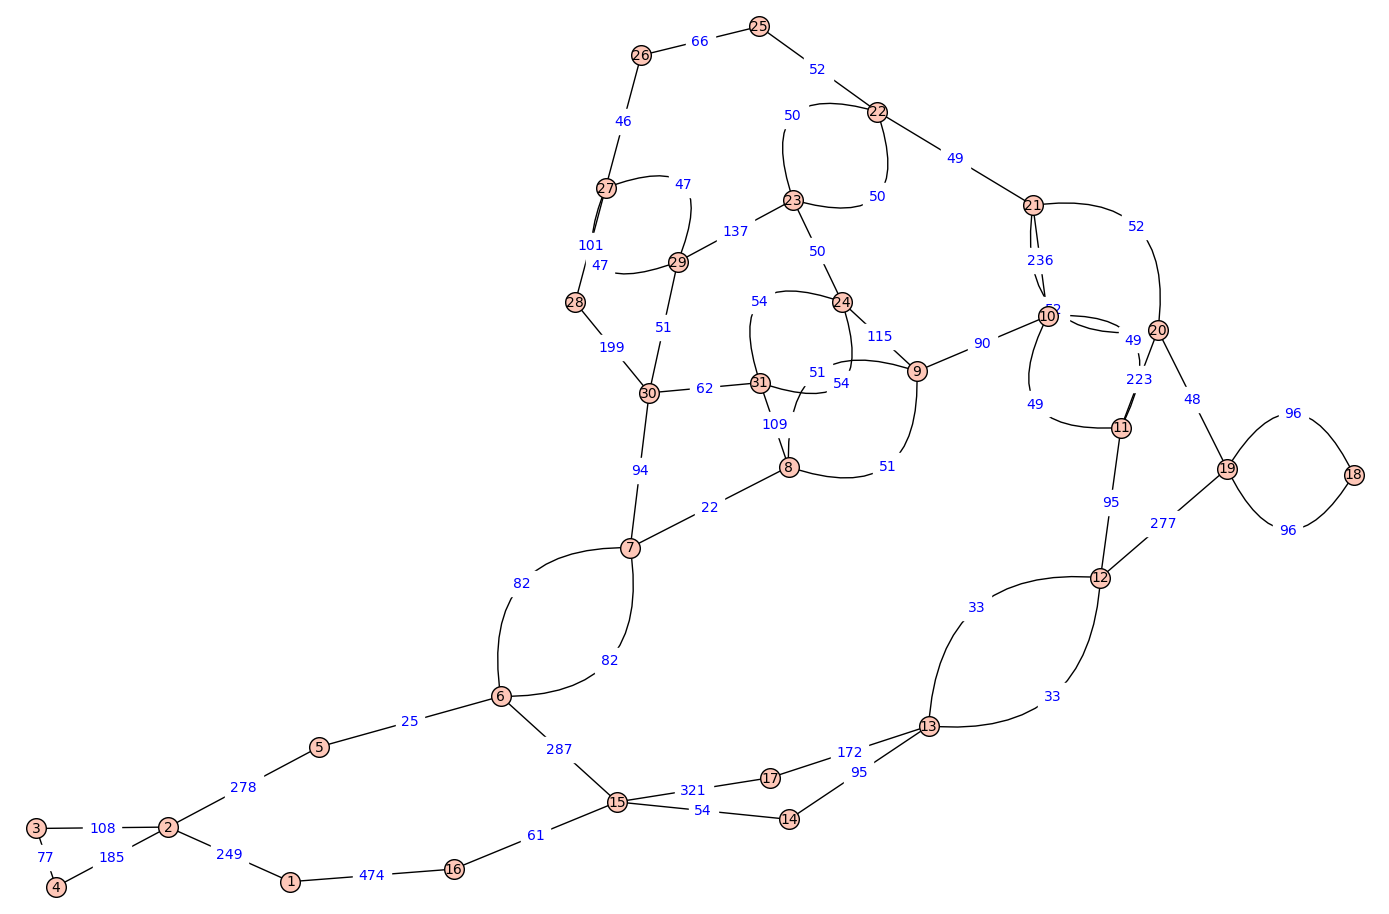

In [22]:
I.show(edge_labels=True, figsize=14)

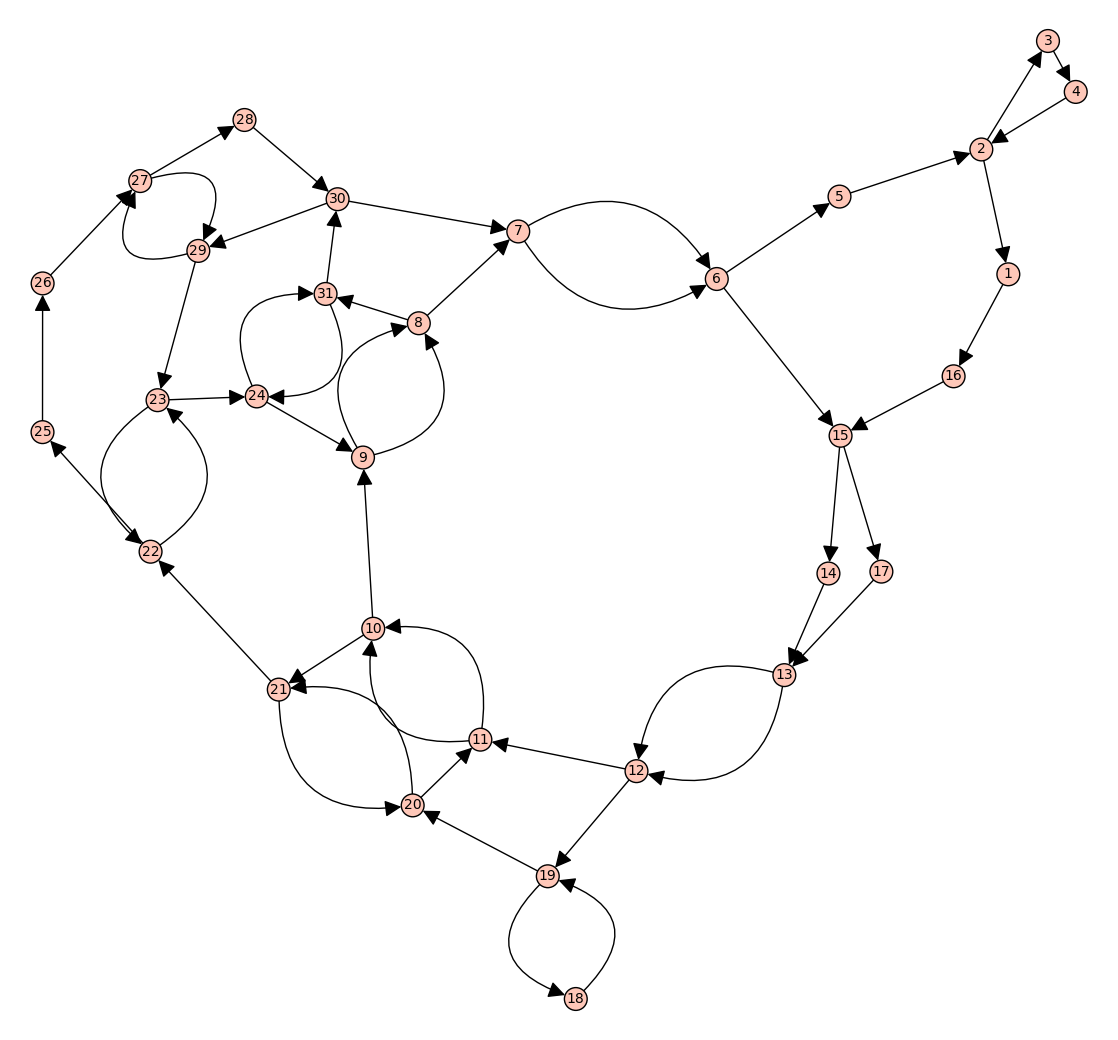

In [23]:
Eulerian = I.eulerian_orientation()
Eulerian.plot(figsize=14, vertex_size=20)